<h1 style="text-align: center;"> Decision Tree Algorithm</h1>

Decision tree Algorithm is a Machine Learning Algorithm that is quite unique from others in a way that it takes a already existing computer science data structure `Tree Data Structure` and enforces strict mathematical rules at each node in order to get a supervised learning algorithm.

There exist many type of tree's such as:

+ CART( Classification and Regression Tree's )
+ ID3 ( Iterative Dichotomiser 3 )
+ C4.5
+ Conditional Inference Tree's
+ CHAID ( Chi-Square Automatic Interaction Detection)

The tree is made up of a root Node, internal nodes and leaf nodes. In general the most widely used decision tree algorithm is the `CART( Classification and Regression Tree's )` which is able to solve problems for both Classification and Regression, but the biggest differentiating factor is that its a binary tree. Meaning at every parent node it splits into exactly two child nodes(left and right).

In order to determine which thershold is best at a given decision node they use mathematical metrics such as Gini Impurity and Entropy for classification, and Log-loss for regression.

<p style="text-align: center;">
    <img src="../images/decision_tree.png">
</p>

Here we can see a simple decision tree, that displays what the thershold for each given node is. Using Information Gain from information theory:

$$IG = \underbrace{\left(-\sum_{k} p_k \log_2 p_k\right)}_{\text{parent entropy}} - \sum_{c \in \{L, R\}} \frac{n_c}{n} \underbrace{\left(-\sum_{k} p_{k}^{(c)} \log_2 p_{k}^{(c)}\right)}_{\text{child } c \text{ entropy}}$$

Where:
* $p_k$ is the proportion of class $k$ in the parent node
* $p_{k}^{(c)}$ is the proportion of class $k$ within child $c$ (left or right)
* $n_c$ is the number of samples in child $c$
* $n$ is the total number of samples in the parent node
* The outer sum $\sum_{c \in \{L, R\}}$ iterates over the two children (left and right)
* The inner sums $\sum_{k}$ iterate over every class $k$, once for the parent and once within each child
* Each child's entropy is weighted by its sample fraction $\frac{n_c}{n}$ before being subtracted

You iterate this Information Gain function over all `features x thresholds` and over each iteration if you get a new higher information gain than the previous one you store it, and at the end you choose whatever feature and threshold for that feature gives you the best information gain, and append that to the node.

<h2 style="text-align: center;"> Decision Tree Algorithm</h2>

<p style="text-align: center;">
    <img src="../images/best_split_search_loop.png">
</p>


In [206]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


"""
    A 
"""


X = np.array([
    [  0.15,  -0.42],
    [ -1.31,   1.21],
    [  1.04,   0.46],
    [ -0.40,   1.63],
    [  1.82,  -1.16],
    [  0.30,   1.29],
    [ -1.20,   0.37],
    [  0.40,  -0.18],
    [  0.80,   0.13],
    [ -1.01,  -0.74],
    [  1.51,  -0.49],
    [ -3.54,   0.51],
    [ -2.91,   3.26],
    [  2.77,  -4.49],
    [  0.39,  -3.31],
    [ -1.69,   3.96],
    [ -4.38,  -2.15],
    [ -0.76,   4.61],
    [ -3.99,   1.22],
    [ -2.12,   2.80],
    [ -2.32,  -3.53],
    [ -2.70,   2.86],
])

y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

<Axes: >

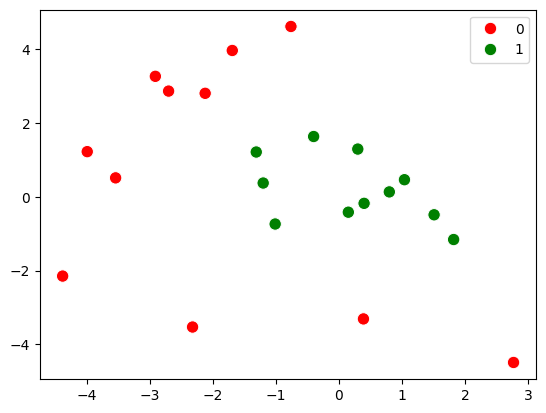

In [207]:
# scatter, colored by class
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette={1: 'green', 0: 'red'}, s=80)

## Entropy (Impurity Measure)

Entropy measures how mixed the class labels are in a group of samples. A pure group (all one class) has entropy 0, a perfectly mixed 50/50 group has entropy 1.

$$H = -\sum_{k} p_k \log_2(p_k)$$

Where:
* $p_k$ is the proportion of samples belonging to class $k$ in the group
* The sum runs over every class $k$ present
* The negative sign makes the result positive, since $\log_2$ of a probability (between 0 and 1) is always negative

## Information Gain (Mathematical Notation)

Information gain measures how much impurity is removed by a split. It compares the parent's entropy to the weighted entropy of the two children it produces.

$$IG = H(\text{parent}) - \left[\frac{n_L}{n} H(\text{left}) + \frac{n_R}{n} H(\text{right})\right]$$

Where:
* $H(\text{parent})$ is the entropy of the node before splitting
* $H(\text{left})$ and $H(\text{right})$ are the entropies of the two child groups
* $n_L$ and $n_R$ are the number of samples in the left and right children
* $n$ is the total number of samples in the parent ($n = n_L + n_R$)
* The weights $\frac{n_L}{n}$ and $\frac{n_R}{n}$ scale each child's entropy by its share of the samples

## Information Gain (Computational Notation)

The same formula expressed in terms closer to how it maps onto code, where $D$ is the dataset at the node and $D_{left}$, $D_{right}$ are the partitions after splitting:

$$IG(D, \text{split}) = H(D) - \sum_{c \in \{left, right\}} \frac{|D_c|}{|D|} H(D_c)$$

Where:
* $D$ is the set of samples at the current node
* $D_c$ is a child partition ($D_{left}$ or $D_{right}$)
* $|D_c|$ is the number of samples in that child (the size of the set)
* $|D|$ is the total number of samples at the node
* The sum iterates over both child partitions, weighting each child's entropy $H(D_c)$ by its fraction of the total $\frac{|D_c|}{|D|}$

In [208]:
def entropy(label):
    entropy_total = 0
    total_items = len(label)
    values, subset_items_k = np.unique(label, return_counts=True)
    
    for k in subset_items_k:
        probability_k = k / total_items
        entropy_total += probability_k*np.log2(probability_k)
    
    return -entropy_total


def information_gain(parent_labels, left_labels, right_labels):
    
    n_parent = len(parent_labels)
    
    weighted_left = (len(left_labels) / n_parent) * entropy(left_labels)
    weighted_right = (len(right_labels) / n_parent) * entropy(right_labels)
    
    return entropy(parent_labels) - (weighted_left + weighted_right)


def best_split(X, y):
    best_gain = -1
    best_feature = None
    best_threshold = None

    n_features = X.shape[1]

    for feature in range(n_features):
        
        values = np.unique(X[:, feature])
        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:
            mask = X[:, feature] <= threshold
            left_labels = y[mask]
            right_labels = y[~mask]

            # skip splits that put everything on one side
            if len(left_labels) == 0 or len(right_labels) == 0:
                continue

            gain = information_gain(y, left_labels, right_labels)

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_gain
    

In [209]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, prediction=None):
        self.feature = feature          
        self.threshold = threshold      
        self.left = left                
        self.right = right              
        self.prediction = prediction    

    def is_leaf(self):
        return self.prediction is not None


def build_tree(X, y, depth=0, max_depth=5, min_samples_split=2):
    # stopping condition to become a leaf
    if len(np.unique(y)) == 1 or len(y) < min_samples_split or depth >= max_depth:
        majority_class = np.bincount(y).argmax()
        return Node(prediction=majority_class)

    feature, threshold, gain = best_split(X, y)

    # no split improves anything -> leaf
    if gain <= 0 or feature is None:
        majority_class = np.bincount(y).argmax()
        return Node(prediction=majority_class)

    # apply the split, recurse into both children
    mask = X[:, feature] <= threshold
    left_child = build_tree(X[mask], y[mask], depth + 1, max_depth, min_samples_split)
    right_child = build_tree(X[~mask], y[~mask], depth + 1, max_depth, min_samples_split)

    return Node(feature=feature, threshold=threshold, left=left_child, right=right_child)


def predict_one(node, x):
    # walk down the tree until reaching a leaf
    if node.is_leaf():
        return node.prediction
    if x[node.feature] <= node.threshold:
        return predict_one(node.left, x)
    else:
        return predict_one(node.right, x)


def predict(node, X):
    return np.array([predict_one(node, x) for x in X])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tree = build_tree(X_train,y_train)
result = predict(tree, X_test)

accuracy = (result == y_test).mean()
print("result:", result)
print("Actual:", y_test)
print("Accuracy:", accuracy)

result: [1 0 1 0 1]
Actual: [1 0 0 0 1]
Accuracy: 0.8


In [210]:
def plot_boundary(X, y, tree, title="Decision boundary"):
    pad = 1.0
    x_min, x_max = X[:,0].min()-pad, X[:,0].max()+pad
    y_min, y_max = X[:,1].min()-pad, X[:,1].max()+pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(tree, grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.25, levels=[-0.5,0.5,1.5], colors=['red','green'])
    plt.scatter(X[y==1,0], X[y==1,1], c='green', edgecolor='k', s=80, label='class 1')
    plt.scatter(X[y==0,0], X[y==0,1], c='red', edgecolor='k', s=80, label='class 0')
    plt.title(title)
    plt.xlabel('feature 0 (x)'); plt.ylabel('feature 1 (y)')
    plt.legend()
    plt.show()

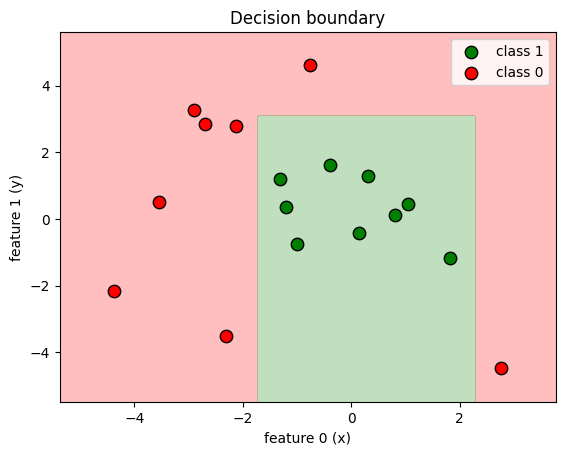

In [211]:
tree = build_tree(X_train, y_train)
plot_boundary(X_train, y_train, tree)

In [212]:
X = np.array([
    [ -2.85,  -0.17],
    [ -2.38,   0.60],
    [ -3.63,  -0.89],
    [ -2.97,   0.71],
    [ -1.82,   0.36],
    [ -1.81,  -1.90],
    [ -4.12,   0.24],
    [ -3.88,  -0.96],
    [ -4.35,  -0.34],
    [ -3.18,  -0.87],
    [ -4.41,   0.77],
    [  2.82,   1.38],
    [  1.97,  -0.49],
    [  3.13,  -1.63],
    [  3.84,   0.61],
    [  2.42,   0.23],
    [  2.17,  -0.55],
    [  2.66,  -1.10],
    [  4.31,  -0.37],
    [  4.43,  -0.12],
    [  3.52,  -0.92],
    [  4.21,  -0.83],
])

y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tree = build_tree(X_train,y_train)
result = predict(tree, X_test)

accuracy = (result == y_test).mean()
print("result:", result)
print("Actual:", y_test)
print("Accuracy:", accuracy)

result: [1 0 0 0 1]
Actual: [1 0 0 0 1]
Accuracy: 1.0


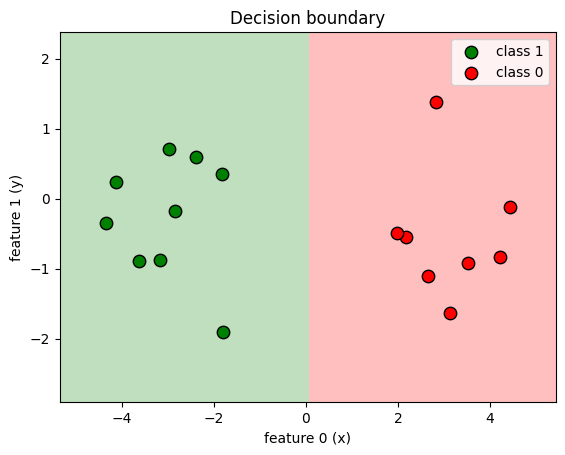

In [213]:
tree = build_tree(X_train, y_train)
plot_boundary(X_train, y_train, tree)